# South Qoroq ca. 1163 Ma paleomagnetic pole

Site-mean directions for the South Qoroq intrusion are compiled from Piper (1992), Table 5, in `../data/1163_South_Qoroq/`. This notebook recalculates the site-VGP Fisher pole and compares it with the Piper/Evans direction-derived pole.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Nine site means are loaded from the study-specific MagIC contribution. VGPs are computed from the site directions at 61.2 N, 314.6 E, the representative locality used in the previous compilation.

In [2]:
sites = pd.read_csv('../data/1163_South_Qoroq/sites.txt', sep='	', skiprows=1)
sites = sites[sites['result_quality'] == 'g'].reset_index(drop=True)
study_lat, study_lon = 61.2, 314.6
numeric_cols = ['dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95', 'dir_n_samples']
for col in numeric_cols:
    sites[col] = pd.to_numeric(sites[col], errors='coerce')

vgp_lon, vgp_lat, vgp_dp, vgp_dm = [], [], [], []
for _, r in sites.iterrows():
    plon, plat, dp, dm = pmag.dia_vgp(r['dir_dec'], r['dir_inc'], r['dir_alpha95'], study_lat, study_lon)
    vgp_lon.append(round(plon % 360, 1))
    vgp_lat.append(round(plat, 1))
    vgp_dp.append(dp)
    vgp_dm.append(dm)

sites = sites.assign(vgp_lon=vgp_lon, vgp_lat=vgp_lat, vgp_dp=vgp_dp, vgp_dm=vgp_dm)

print(f'{len(sites)} South Qoroq sites; {int(sites["dir_n_samples"].sum())} samples')
sites[['site', 'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95', 'dir_n_samples', 'vgp_lat', 'vgp_lon', 'description']]

9 South Qoroq sites; 67 samples


,site,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,vgp_lat,vgp_lon,description
0,1,275,47,52,8,7,26.8,234.9,"Site-mean directions from Piper (1992), Table 5."
1,2,275,58,43,9,7,35.5,241.8,"Site-mean directions from Piper (1992), Table 5."
2,3,298,47,23,12,8,37.8,214.8,"Site-mean directions from Piper (1992), Table 5."
3,4,265,54,26,14,6,27.5,246.9,"Site-mean directions from Piper (1992), Table 5."
4,5,346,43,35,10,8,52.6,155.7,"Site-mean directions from Piper (1992), Table 5."
5,6,304,66,25,11,8,56.5,228.1,"Site-mean directions from Piper (1992), Table 5."
6,7,303,41,44,9,7,36.2,206.9,"Site-mean directions from Piper (1992), Table 5."
7,8,315,45,17,19,5,44.2,196.4,"Site-mean directions from Piper (1992), Table 5."
8,9,308,40,36,8,11,37.8,201.4,Contact site in Eriksfjord lavas


## Mean direction

The site directions form a single positive-inclination cluster, so the direction mean is calculated without polarity unification.

Dec: 300.1  Inc: 51.4
Number of directions in mean (n): 9
Angular radius of 95% confidence (a_95): 11.7
Precision parameter (k) estimate: 20.2
Piper (1992) group mean direction: 299.9/51.2, alpha95 12
direction-derived pole: 42.0 N / 215.5 E, dp/dm 10.8/16.0, geometric A95 13.1
Piper (1992) / Evans et al. (2021): 41.8 N / 215.9 E, dp/dm 10.8/15.9, A95 13.1


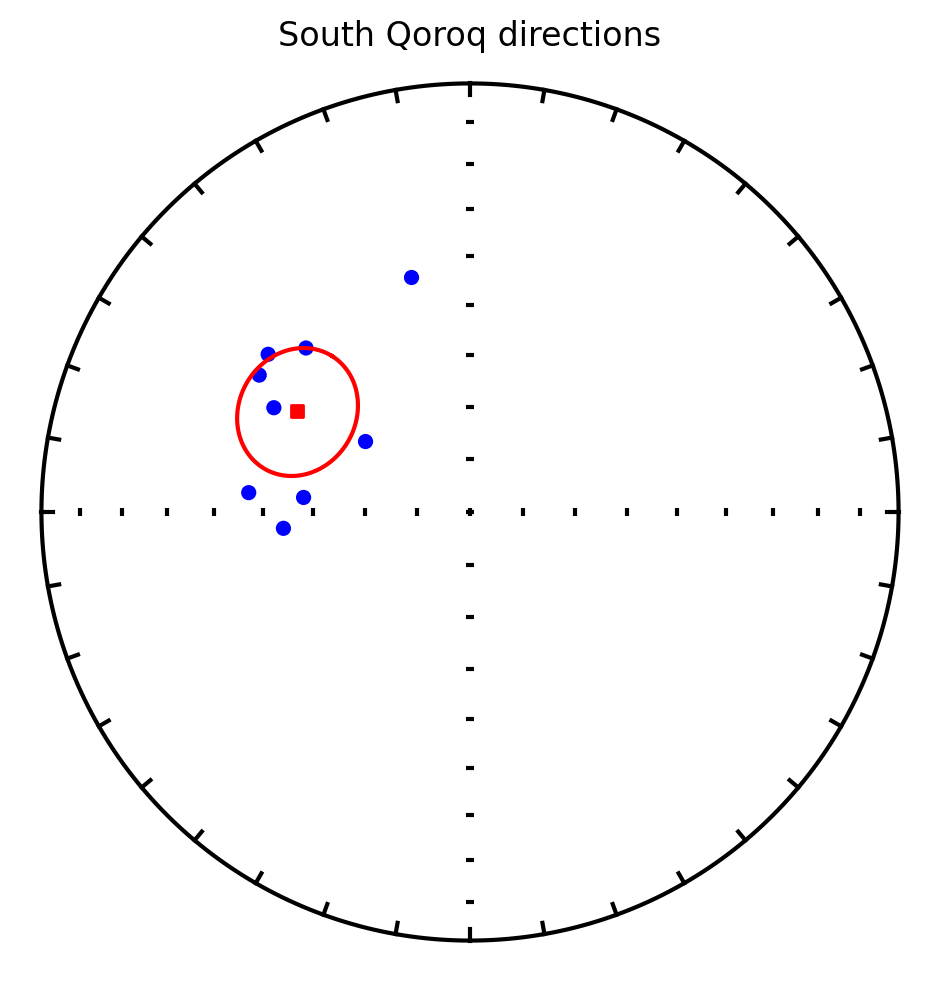

In [3]:
dir_block, dir_mean = pt.compute_mean_direction(sites, unify_polarity=False)
ipmag.print_direction_mean(dir_mean)
print('Piper (1992) group mean direction: 299.9/51.2, alpha95 12')

plon_dir, plat_dir, dp_dir, dm_dir = pmag.dia_vgp(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], study_lat, study_lon)
dir_pole = {'dec': plon_dir % 360, 'inc': plat_dir, 'dp': dp_dir, 'dm': dm_dir, 'alpha95': (dp_dir * dm_dir) ** 0.5}
print(f"direction-derived pole: {dir_pole['inc']:.1f} N / {dir_pole['dec']:.1f} E, dp/dm {dir_pole['dp']:.1f}/{dir_pole['dm']:.1f}, geometric A95 {dir_pole['alpha95']:.1f}")
print('Piper (1992) / Evans et al. (2021): 41.8 N / 215.9 E, dp/dm 10.8/15.9, A95 13.1')

ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], color='red', marker='s')
plt.title('South Qoroq directions')
plt.show()

## Mean pole from site VGPs

The recalculated site-VGP Fisher pole is close to, but not identical with, the published direction-derived pole because Piper (1992) reports the pole from the group mean direction and its confidence ellipse.

Plon: 217.0  Plat: 42.2
Number of directions in mean (n): 9
Angular radius of 95% confidence (A_95): 14.9
Precision parameter (k) estimate: 13.0
Piper (1992) / Evans et al. (2021) direction-derived pole: 41.8 N / 215.9 E, A95 13.1


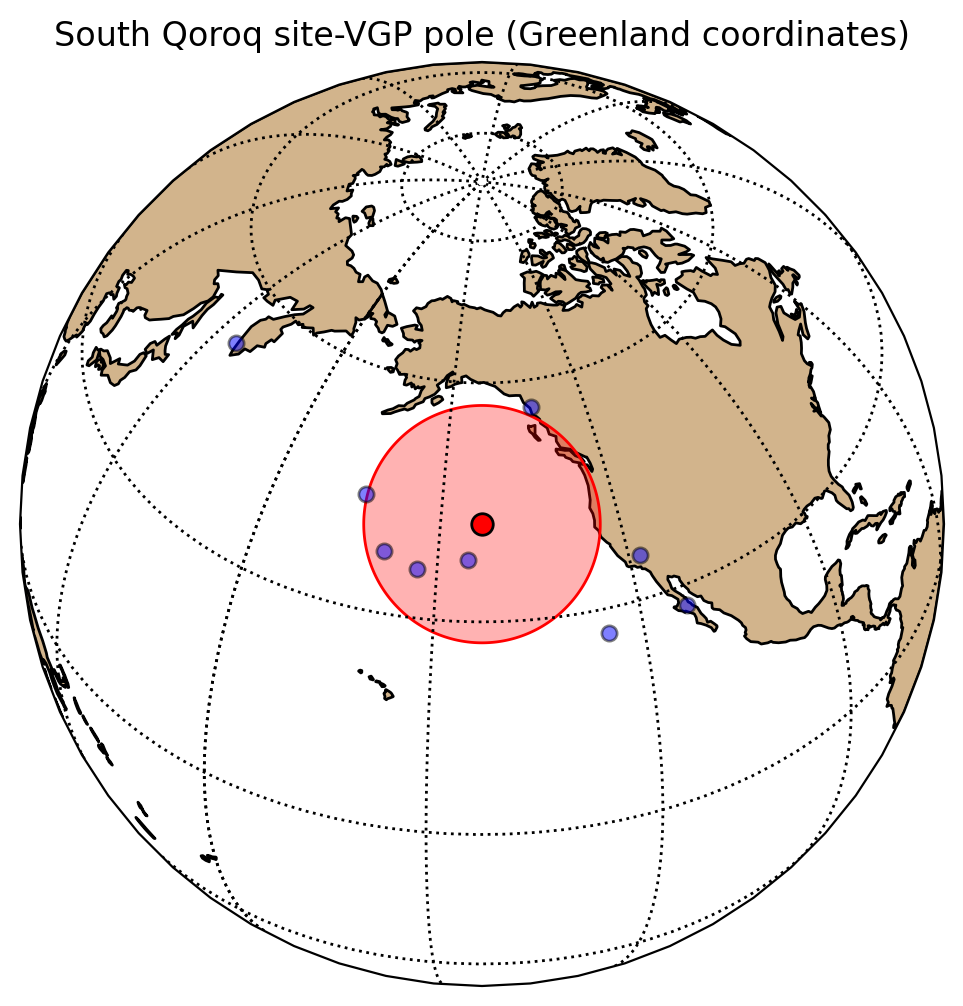

In [4]:
vgp_block, pole_mean = pt.compute_mean_pole(sites, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('Piper (1992) / Evans et al. (2021) direction-derived pole: 41.8 N / 215.9 E, A95 13.1')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('South Qoroq site-VGP pole (Greenland coordinates)')
plt.show()

## Paleosecular variation and R2

In [5]:
r2_result = pt.assess_R2(sites, pole_mean)
print()
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

R2 assessment (Meert et al., 2020):
  (a) two demag methods (AF + thermal)  [advisory, from method_codes]: no
  (b) PCA / great-circle component analysis  [advisory, from method_codes]: no
      note: method codes are inconsistently applied; confirm (a)/(b) against the source publication.
  (c) adequate PSV sampling [scored]:
        N = 67 samples (>= 25): PASS
        K = 13.0 (10-70): PASS
        B = 9 sites (>= 8): PASS
        min 5 samples/site (>= 3): PASS
        A95 = 14.9 in Deenen envelope [5.0, 20.5]: PASS
  => R2 (from sub-criterion c) = 1

A_95 of 14.9 passes Deenen et al. (2011) criteria of being between 5.0 and 20.5 for this number of sites


<Axes: title={'center': 'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

## Laurentia reference frame

unrotated (present-day Greenland frame): 42.2 N / 217.0 E, A95 14.9
rotated into the Laurentia frame:        44.8 N / 208.6 E, A95 14.9


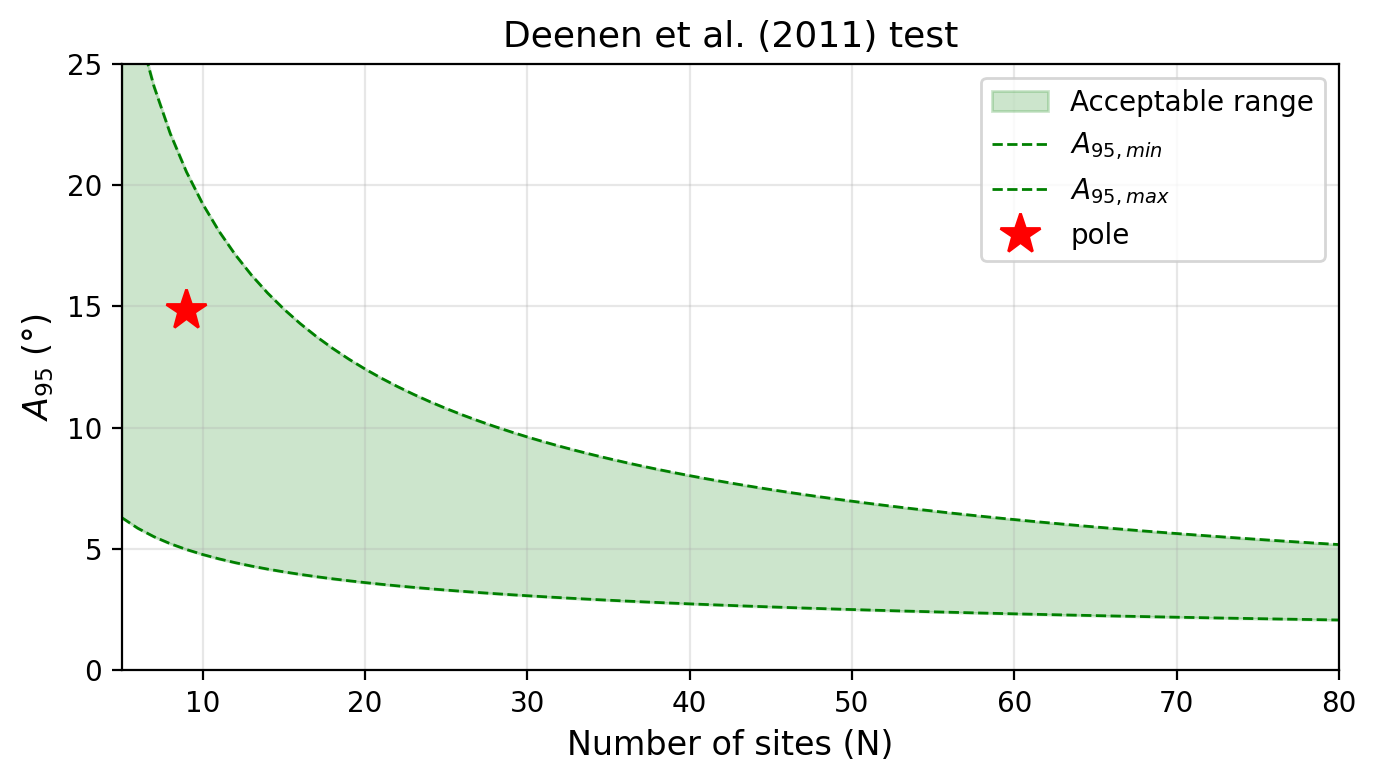

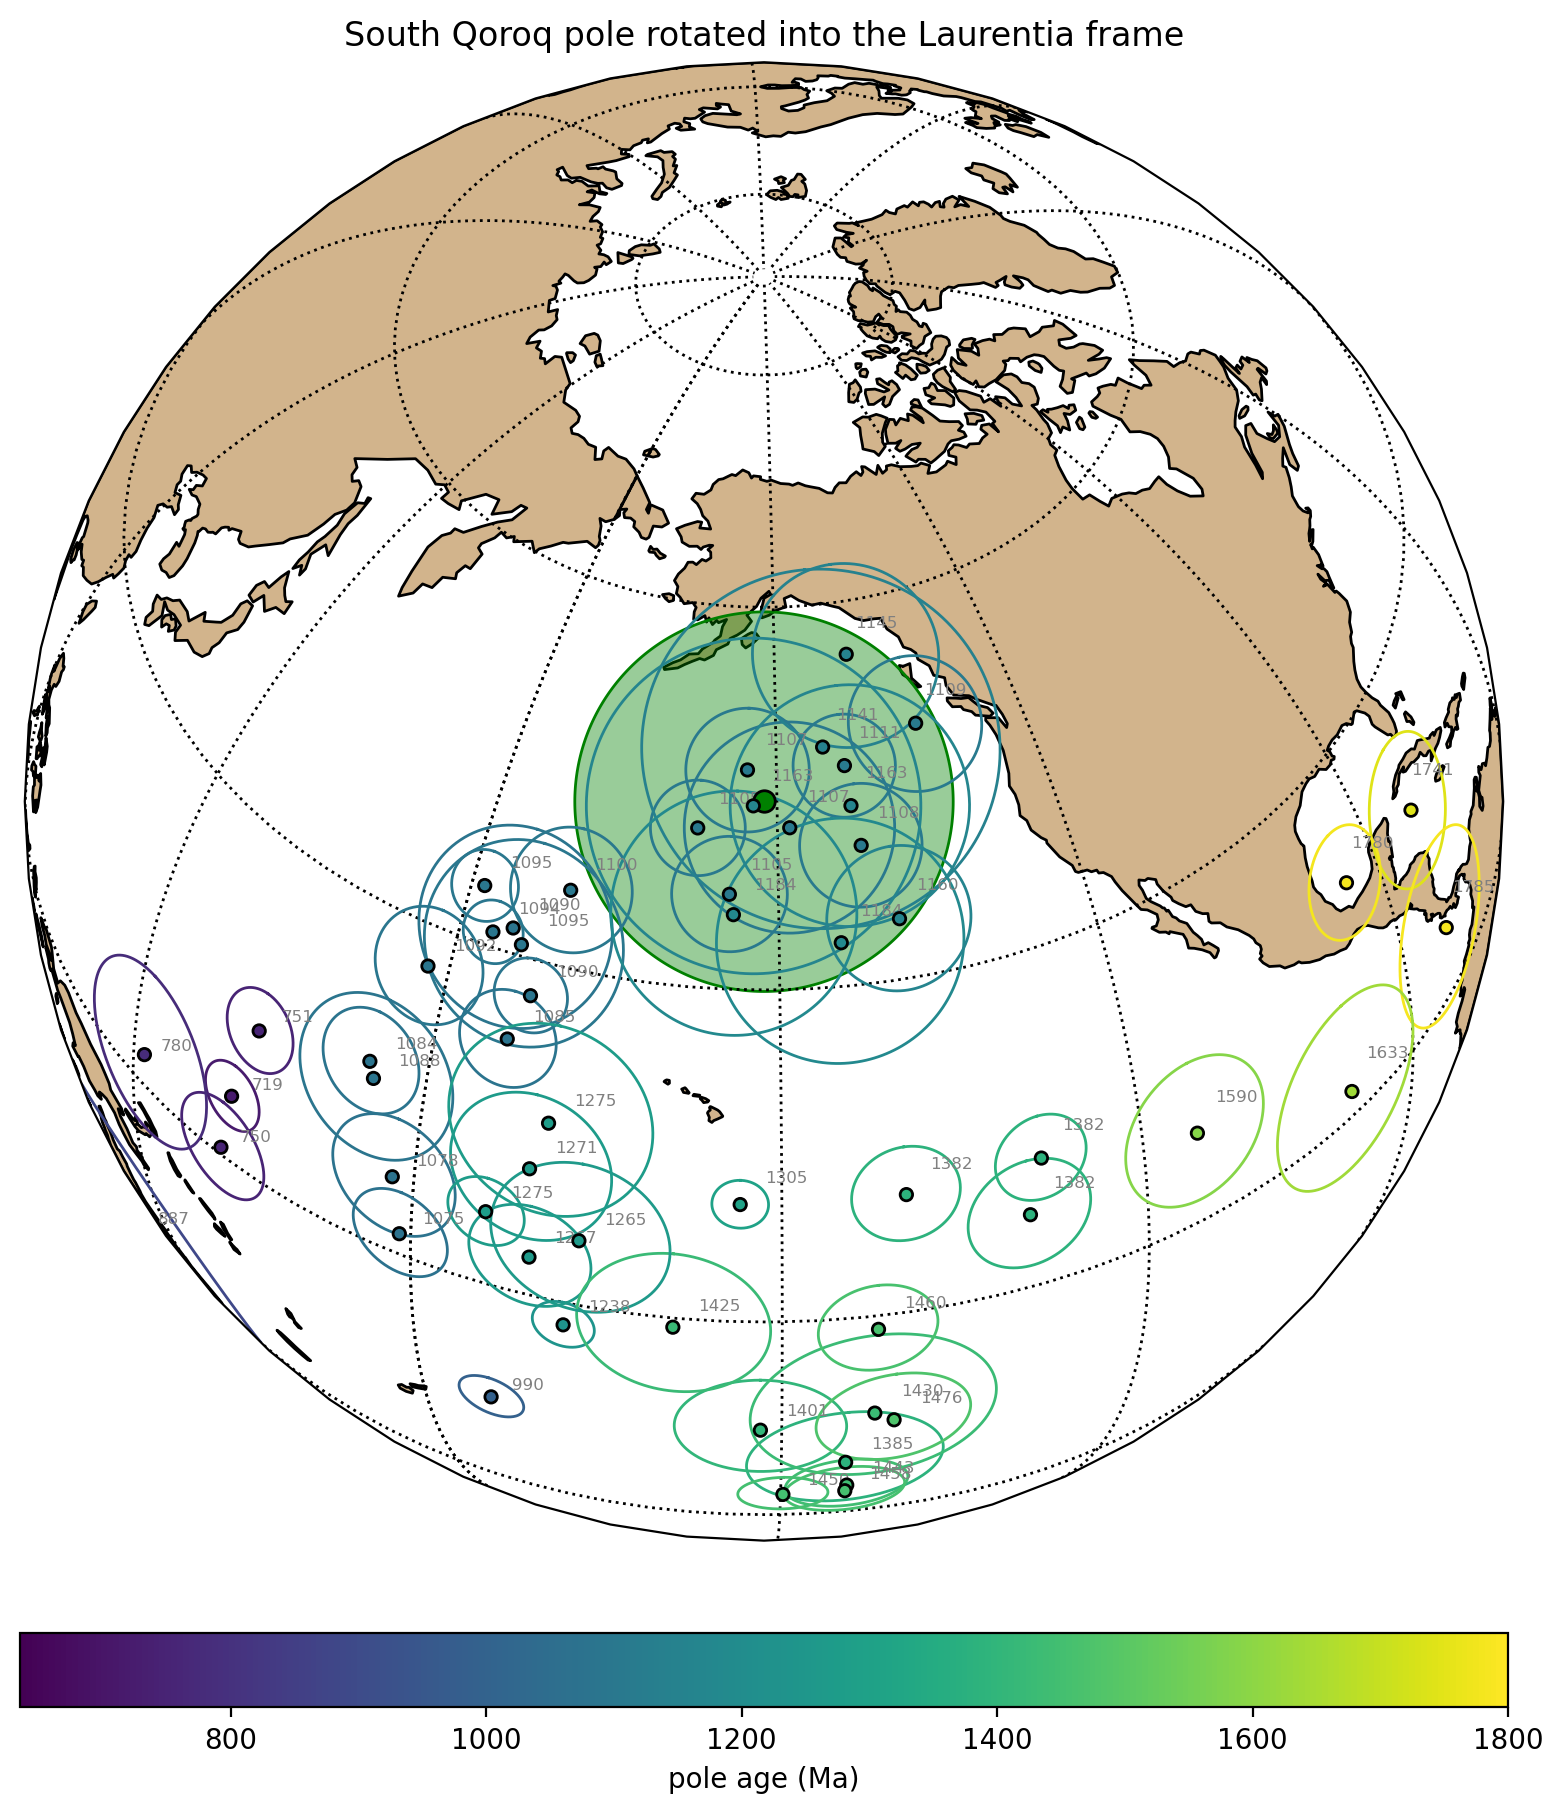

In [6]:
EULER_GREENLAND = pt.TERRANE_EULER_POLES['Laurentia-Greenland']
_rlat, _rlon = pmag.pt_rot(EULER_GREENLAND, [pole_mean['inc']], [pole_mean['dec']])
pole_rot = {'inc': _rlat[0], 'dec': _rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"unrotated (present-day Greenland frame): {pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E, A95 {pole_mean['alpha95']:.1f}")
print(f"rotated into the Laurentia frame:        {pole_rot['inc']:.1f} N / {pole_rot['dec']:.1f} E, A95 {pole_rot['alpha95']:.1f}")

ax = pt.plot_apwp_context(Laurentia_poles, pole_rot['inc'], pole_rot['dec'],
                          pole_rot['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_rot['dec'],
                          central_latitude=pole_rot['inc'])
plt.title('South Qoroq pole rotated into the Laurentia frame')
plt.show()

## Comparison with younger Laurentia poles

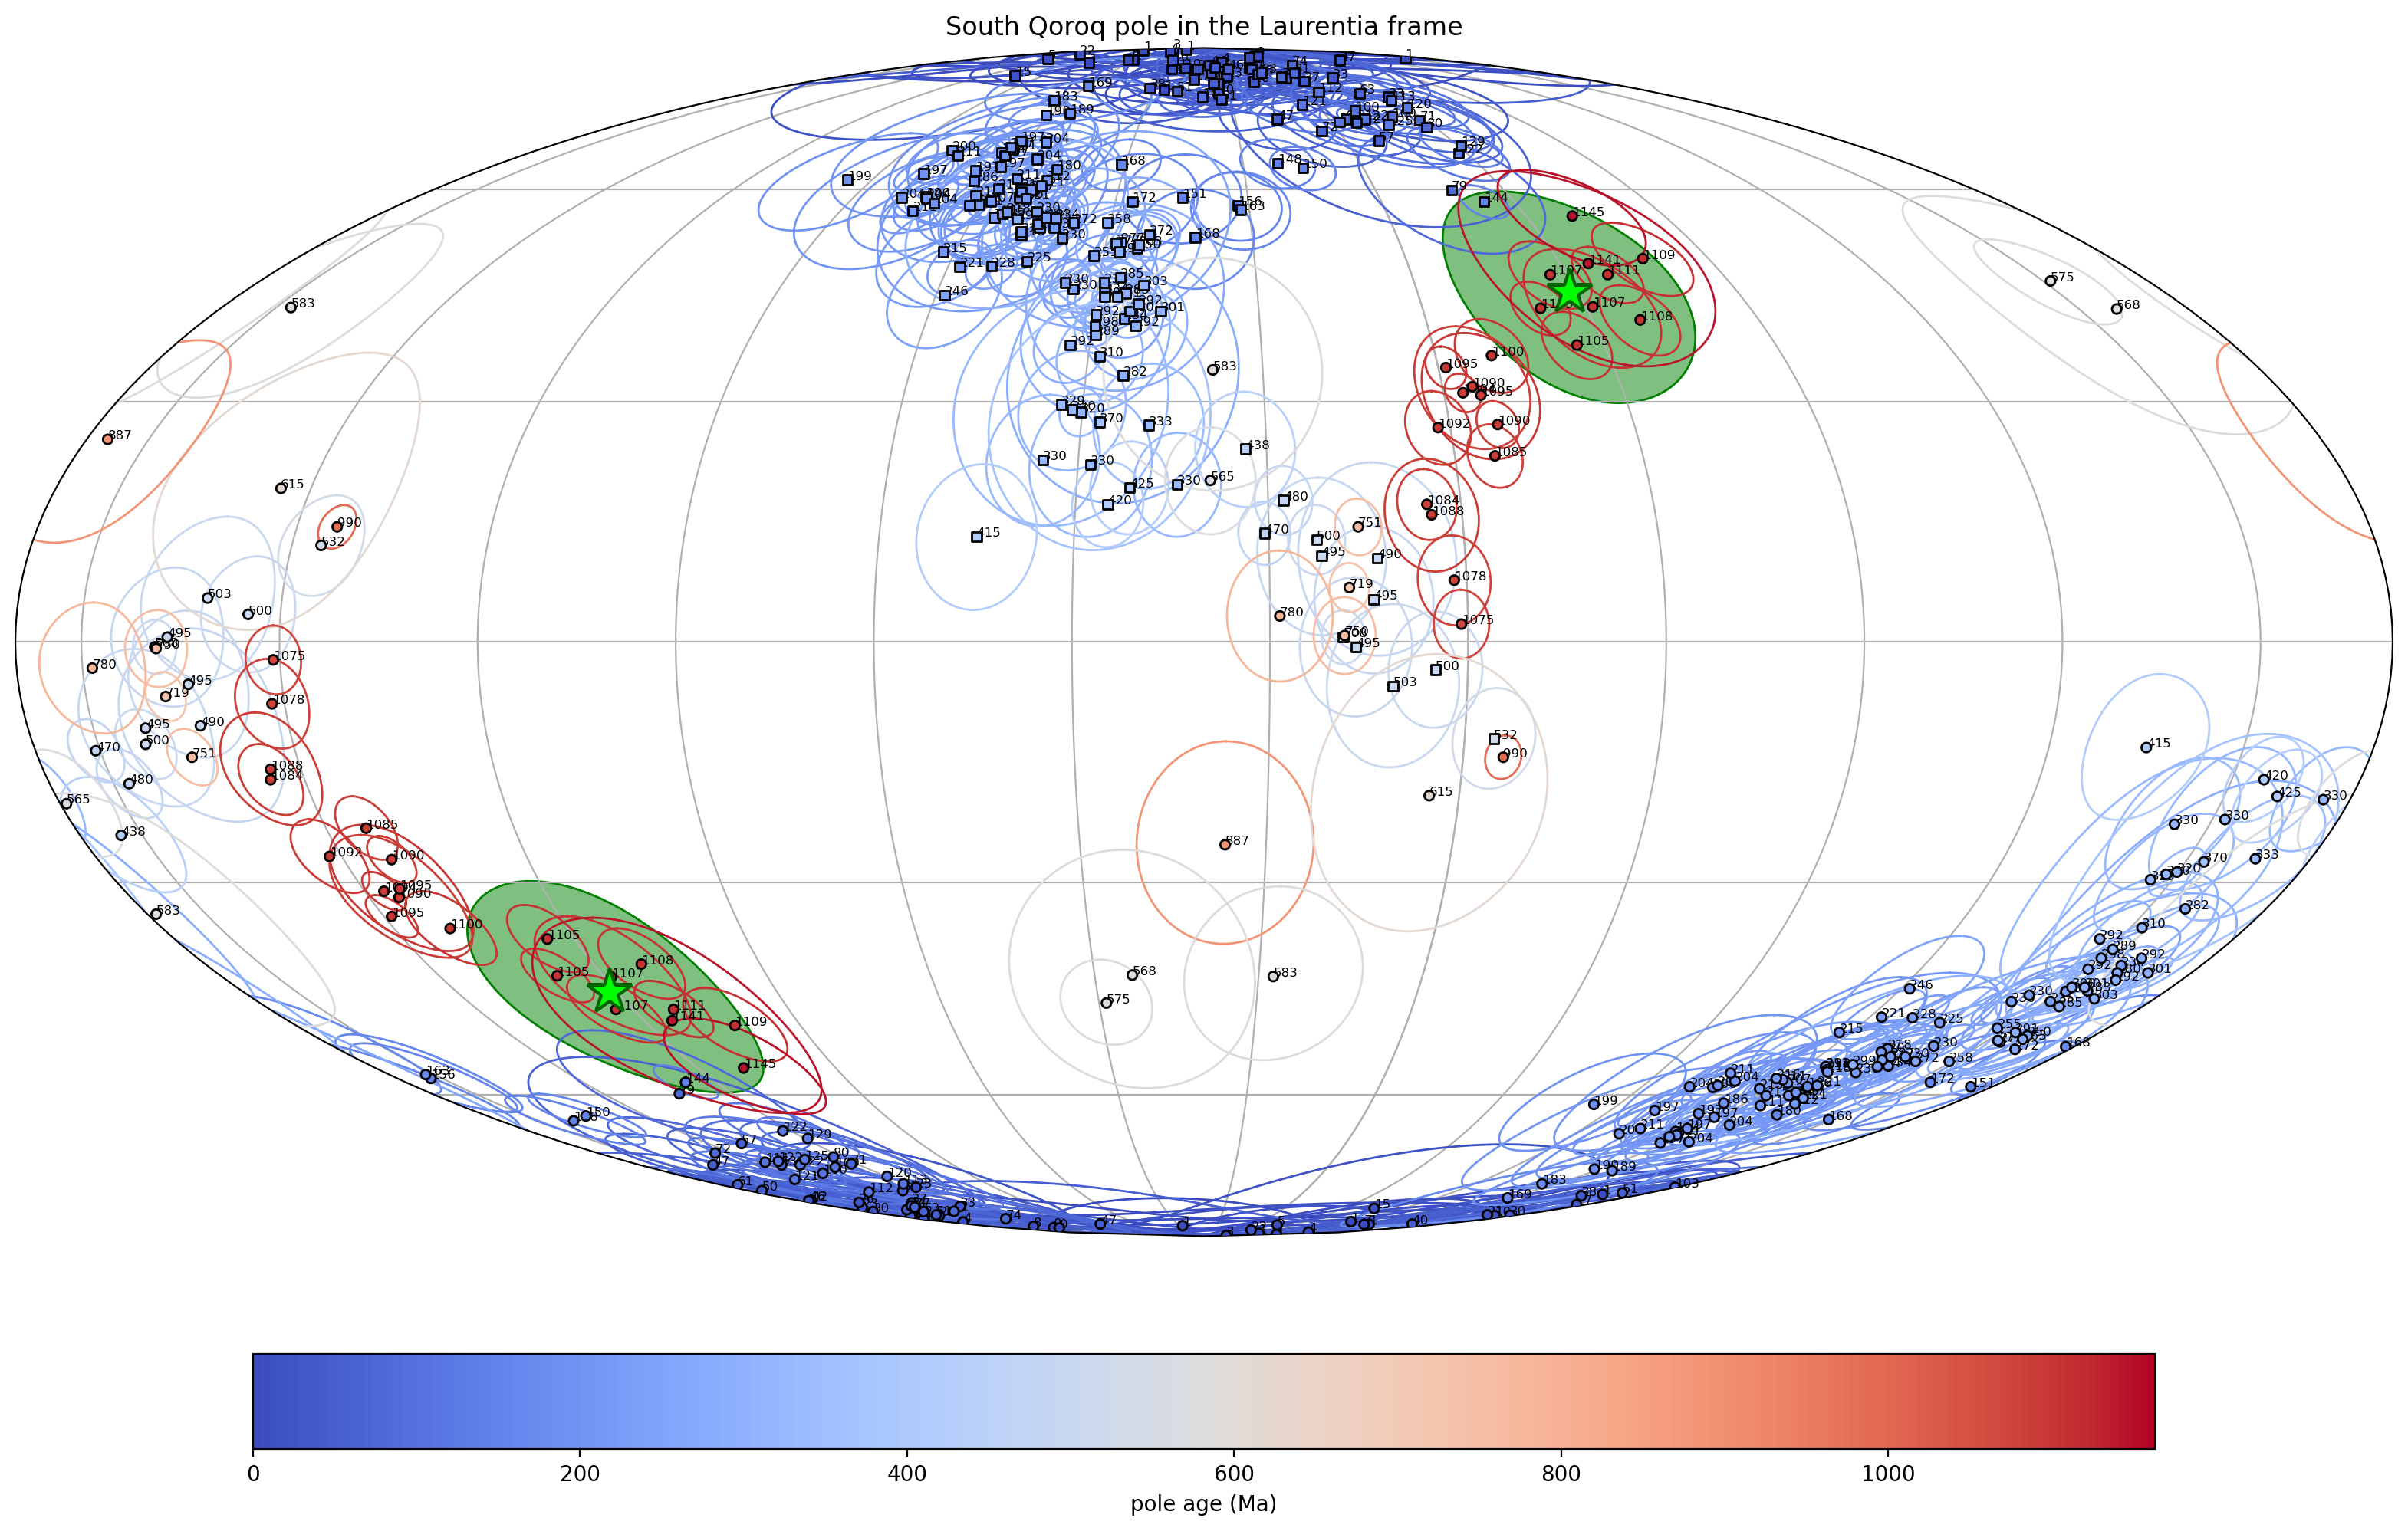

In [7]:
pt.plot_pole_overlap('South Qoroq Intrusion', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_rot['inc'], pole_plon=pole_rot['dec'],
                     pole_A95=pole_rot['alpha95'], pole_age=1163, show=False)
plt.title('South Qoroq pole in the Laurentia frame')
plt.show()

## Nordic workshop summary

The exported pole is the recalculated site-VGP Fisher mean in present-day Greenland coordinates. The comment records the direction-derived comparison with Piper (1992) and Evans et al. (2021).

In [8]:
summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='South Qoroq Intrusion',
    sites=sites,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Characteristic remanent magnetization; mean for the South Qoroq intrusion (Gardar Province, South Greenland)',
    tests='',
    gpmdb_number='',
    magic_id='',
    percent_reversed='',
    demag_code='',
    R1=1, R2=int(r2_result['R2']), R3=1, R4='C', R5=0, R6=0, R7=1, Grade='A',
    nominal_age=1163, lomagage=1161, himagage=1165,
    REF_method='This is considered a younger giant dike from the Tugtutoq region with a 1163 +/- 2 Ma U-Pb baddeleyite age unpublished from Heaman.',
    POLE_AUTHORS='Piper, J.D.A.',
    YEAR=1992,
    JOURNAL='Precambrian Res.',
    VOLUME='54',
    VPAGES='153-172',
    TITLE='The palaeomagnetism of major (Middle Proterozoic) igneous complexes, South Greenland and the Gardar apparent polar wander track',
    COMMENT='Recalculated from the nine Piper (1992) Table 5 South Qoroq site means. Site VGP Fisher pole is %.1f N / %.1f E, A95 %.1f. The direction-derived pole from the recalculated mean is %.1f N / %.1f E, dp/dm %.1f/%.1f, matching the Piper/Evans pole within rounding.' % (pole_mean['inc'], pole_mean['dec'], pole_mean['alpha95'], dir_pole['inc'], dir_pole['dec'], dir_pole['dp'], dir_pole['dm'])
)
pt.save_nordic_summary(summary, '1163_South_Qoroq')
summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,South Qoroq Intrusion,,Characteristic remanent magnetization; mean fo...,,0,61.2,314.6,9,67,...,1165,This is considered a younger giant dike from t...,South Qoroq Intrusion,"Piper, J.D.A.",1992,Precambrian Res.,54,153-172,The palaeomagnetism of major (Middle Proterozo...,Recalculated from the nine Piper (1992) Table ...
